# Sales Performance & Risk Analysis
### Acme Co. | US Sales Analytics | 2014-2017

---

## 1. Business Context & Objective

Acme Co. operates a multi-region sales organization across the United States, offering a diverse product portfolio through multiple sales channels. Leadership faces challenges in understanding which regions, products, and channels are driving **sustainable and profitable** growth — and where sales effort should be reallocated to improve margin outcomes.

The objective of this analysis is to evaluate historical sales performance across products, regions, and sales channels in order to:

- Identify key drivers of revenue and profitability
- Benchmark actual performance against available budget targets
- Detect margin erosion signals and revenue concentration risks
- Support data-driven decisions on sales strategy and resource allocation

### Stakeholder
The primary stakeholder is the **VP of Sales / Regional Sales Director**, responsible for achieving revenue targets, optimizing channel strategy, and guiding regional expansion decisions.

### Key Business Questions
1. Which products and sales channels drive the highest profit margins, and where should the business prioritize investment to grow profit — not just revenue?
2. Do regions or channels show signs of margin erosion, or is underperformance purely volume-driven?
3. How concentrated is revenue across products and regions, and what risk does this pose to overall business stability?

---

## 2. Data Overview, Grain & Assumptions

### Data Sources
The analysis uses Acme Co.'s USA regional sales data covering sales activity from **2014 to 2018**. The dataset integrates six related sheets:

| Sheet | Description |
|---|---|
| Sales Orders | Core transaction fact table (64,104 rows) |
| Products | Product name lookup (30 products) |
| Customers | Customer name lookup (175 customers) |
| Regions | Delivery region attributes (994 regions) |
| State Regions | State-to-macro-region mapping (48 states) |
| 2017 Budgets | Product-level revenue targets for 2017 |

### Data Grain

Each row is expected to represent a **sales delivery event** - a specific 
product ordered by a specific customer, delivered to a specific region on 
a given date.

**Assumed grain:** `OrderNumber + OrderDate + Delivery Region Index`

> This assumption will be formally validated in Section 3.2.

### Time Coverage & Exclusions
- **2014–2017**: Full years; used for all trend and annual analyses.
- **2018**: Partial data (January–February only); **excluded** from annual comparisons to prevent bias.
- **Budget data**: Available for 2017 only; used exclusively in the Budget vs. Actual section.

### KPI Definitions

| Metric | Definition |
|---|---|
| Revenue | `Line Total` (recorded transaction revenue) |
| Cost | `Total Unit Cost × Order Quantity` |
| Profit | `Revenue - Cost` |
| Profit Margin | `Profit / Revenue` (transaction-level) |
| Weighted Margin | `Total Profit / Total Revenue` (aggregate-level; preferred for reporting) |

<br>

> **Source data note:** The column `Total Unit Cost` is misnamed in the source file. Validation confirms it represents **cost per unit**, not total line cost. Multiplying by `Order Quantity` yields the correct total cost figure.

> **Weighted vs. Average Margin:** Weighted Margin is used throughout this analysis for aggregate comparisons. Simple-average margin does not account for deal size and can mislead in portfolios with high revenue dispersion.

### Trust Assumptions
- Revenue (`Line Total`) and unit cost (`Total Unit Cost`) values are assumed to be accurately recorded in the source system.
- Profit and margin are derived metrics, not source fields.
- No missing values or structural inconsistencies were identified that would prevent analysis.
- Analysis focuses on internal trend evaluation; no external benchmark data is available.

---

## 3. Data Loading & Initial Validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [2]:
# Load core fact table
file_path = r"regional_sales_dataset.xlsx"

df = pd.read_excel(file_path, sheet_name='Sales Orders')
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,"2,499.10","14,994.60","1,824.34"
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,"2,351.70","25,868.70","1,269.92"
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.20,"5,869.20",684.74
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,"2,338.30","16,368.10","1,028.85"
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,"2,291.40","18,331.20","1,260.27"


In [3]:
df.shape

(64104, 12)

In [4]:
df.columns.to_list()

['OrderNumber',
 'OrderDate',
 'Customer Name Index',
 'Channel',
 'Currency Code',
 'Warehouse Code',
 'Delivery Region Index',
 'Product Description Index',
 'Order Quantity',
 'Unit Price',
 'Line Total',
 'Total Unit Cost']

#### Initial Observations
- Dataset contains **64,104 sales delivery records** spanning 2014–2018, with 12 columns.
- Core financial fields are present: `Line Total` (Revenue) and `Total Unit Cost` (unit-level cost basis).
- Profit and margin will be derived during feature engineering.
- Dimension attributes (customer name, product name, region name, macro-region) reside in separate sheets and will be merged in the enrichment phase.

---

### 3.1 Date Range & Time Coverage Validation

In [5]:
# Convert OrderDate to datetime
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Inspect date range
df['OrderDate'].min(), df['OrderDate'].max()

(Timestamp('2014-01-01 00:00:00'), Timestamp('2018-02-28 00:00:00'))

In [6]:
# Year-level record distribution
df['OrderDate'].dt.year.value_counts().sort_index()

OrderDate
2014    15453
2015    15473
2016    15437
2017    15263
2018     2478
Name: count, dtype: int64

#### Observations
- Data spans **1 January 2014 to 3 February 2018**.
- **2014–2017** are complete calendar years (~15,250-15,475 records each).
- **2018** contains only **2,478 records** covering January-February and will be **excluded** from annual and trend analyses.

---

### 3.2 Order Number & Grain Validation

In [7]:
# Total rows vs unique order numbers
total_rows = len(df)
unique_orders = df['OrderNumber'].nunique()

print(f"Total rows    : {total_rows:,}")
print(f"Unique orders : {unique_orders:,}")
print(f"Rows per order: {total_rows / unique_orders:.1f} (average)")

Total rows    : 64,104
Unique orders : 10,684
Rows per order: 6.0 (average)


In [8]:
# Distribution of rows per OrderNumber
lines_per_order = df.groupby('OrderNumber').size()
lines_per_order.value_counts().sort_index()

6    10684
Name: count, dtype: int64

In [9]:
# Verify one product and one customer per OrderNumber
products_per_order  = df.groupby('OrderNumber')['Product Description Index'].nunique()
customers_per_order = df.groupby('OrderNumber')['Customer Name Index'].nunique()

print(f"Max products per order : {products_per_order.max()}")
print(f"Max customers per order: {customers_per_order.max()}")

Max products per order : 1
Max customers per order: 1


In [10]:
# Identify orders delivered to multiple regions on the same date
same_date_multi_region = (
    df.groupby(['OrderNumber', 'OrderDate'])['Delivery Region Index']
    .nunique()
)
print(f"Cases with split-region delivery on same date: {(same_date_multi_region > 1).sum()}")

Cases with split-region delivery on same date: 101


In [11]:
# Confirm grain: OrderNumber + OrderDate + Delivery Region Index
duplicates_at_grain = df.duplicated(
    subset=['OrderNumber', 'OrderDate', 'Delivery Region Index']
).sum()

print(f"Duplicate rows at confirmed grain: {duplicates_at_grain}")

Duplicate rows at confirmed grain: 0


#### Observations
- Every `OrderNumber` appears **exactly 6 times** across the dataset.
- Each `OrderNumber` maps to exactly **one product and one customer** -
  so `Product Description Index` and `Customer Name Index` are implied 
  by `OrderNumber` and are not required in the grain key.
- 101 cases exist where the same order was delivered to **multiple 
  regions on the same date** - these are legitimate split-delivery events, 
  resolved only by including `Delivery Region Index` in the key.
- **Zero duplicates** at `OrderNumber + OrderDate + Delivery Region Index` -
  grain assumption confirmed.
---

### 3.3 Missing Values & Duplicate Row Check

In [12]:
# Missing values by column
df.isna().sum()

OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64

In [13]:
# Exact duplicate rows
df.duplicated().sum()

np.int64(0)

#### Observations
- **No missing values** in any column.
- **No exact duplicate rows** present.
- Dataset is structurally clean and ready for feature engineering.

---

### Section Summary - Data Loading & Validation

The dataset loaded successfully with 64,104 records and 12 columns. Date coverage spans 2014 to early 2018; 2018 will be excluded from annual analyses. Order structure is intentional - each `OrderNumber` represents a standing order delivered across multiple regions on different dates. Zero missing values and zero duplicates confirm source data integrity. The dataset is ready for feature engineering.

---

## 4. Data Preparation & Feature Engineering

In [14]:
# Derive core financial metrics
# Note: 'Total Unit Cost' is misnamed in source - it is cost per unit, not total cost
df['revenue']       = df['Line Total']
df['cost']          = df['Total Unit Cost'] * df['Order Quantity']   # unit cost × quantity = total cost
df['profit']        = df['revenue'] - df['cost']
df['profit_margin'] = np.where(
    df['revenue'] != 0,
    df['profit'] / df['revenue'],
    np.nan
)

df[['revenue', 'cost', 'profit', 'profit_margin']].describe()

,revenue,cost,profit,profit_margin
count,"64,104.00","64,104.00","64,104.00","64,104.00"
mean,"19,280.68","12,077.19","7,203.49",0.37
std,"15,429.60","10,180.43","6,626.12",0.13
min,837.50,351.75,125.62,0.15
25%,"8,019.90","4,793.85","2,542.55",0.26
50%,"14,023.10","8,789.56","5,091.46",0.37
75%,"27,416.40","16,816.46","9,922.16",0.49
max,"78,711.60","65,330.63","45,559.46",0.60


#### Observations
- All financial metrics derived without errors or null values.
- **Profit margins range from 15% to 60%**, with a mean of ~37.4% and median of ~37.0% — indicating a realistic and stable cost-to-price structure.
- Mean and median are closely aligned, reflecting moderate and controlled right skew.


In [15]:
# Derive time-based features
df['year']       = df['OrderDate'].dt.year
df['month']      = df['OrderDate'].dt.month
df['year_month'] = df['OrderDate'].dt.to_period('M')

df[['OrderDate', 'year', 'month', 'year_month']].head()

,OrderDate,year,month,year_month
0,2014-01-01,2014,1,2014-01
1,2014-01-01,2014,1,2014-01
2,2014-01-01,2014,1,2014-01
3,2014-01-01,2014,1,2014-01
4,2014-01-01,2014,1,2014-01


In [16]:
# Create analysis dataset - exclude partial 2018 data
df_analysis = df[df['year'] < 2018].copy()

df_analysis['year'].value_counts().sort_index()

year
2014    15453
2015    15473
2016    15437
2017    15263
Name: count, dtype: int64

In [17]:
# Validate no nulls in engineered fields
df_analysis[['revenue', 'cost', 'profit', 'profit_margin']].isna().sum()

revenue          0
cost             0
profit           0
profit_margin    0
dtype: int64

In [18]:
# Sanity check on distributions in analysis dataset
df_analysis[['revenue', 'cost', 'profit', 'profit_margin']].describe()

,revenue,cost,profit,profit_margin
count,"61,626.00","61,626.00","61,626.00","61,626.00"
mean,"19,274.96","12,071.54","7,203.43",0.37
std,"15,433.58","10,180.39","6,626.81",0.13
min,837.50,351.75,125.62,0.15
25%,"7,999.80","4,793.18","2,538.03",0.26
50%,"14,023.10","8,779.68","5,102.18",0.37
75%,"27,416.40","16,799.58","9,929.40",0.49
max,"78,711.60","65,330.63","45,559.46",0.60


#### Observations
- `df_analysis` contains **61,626 records** across 2014–2017; 2018 successfully excluded.
- Temporal features (`year`, `month`, `year_month`) enable trend decomposition and seasonal analysis.
- Revenue and profit distributions show consistent scaling across transactions, with realistic margins across the full range.

---

### Section Summary — Feature Engineering

Raw transaction data has been transformed into analysis-ready financial metrics. `df_analysis` (2014-2017) is the validated working dataset for all subsequent analyses. Cost derivation corrects for the source column's misleading name. The dataset is ready for dimension enrichment.

---

## 5. Data Enrichment & Dimension Merging

### Business Purpose
Merge reference dimension sheets to make data human-readable for business analysis, without altering grain or introducing row-level duplication.

### 5.1 Load All Reference Sheets

In [19]:
# Inspect available sheets
xls = pd.ExcelFile(file_path)
print("Available sheets:", xls.sheet_names)

Available sheets: ['Sales Orders', 'Customers', 'Regions', 'State Regions', 'Products', '2017 Budgets']


In [20]:
# Load all dimension and reference tables
sales_raw   = pd.read_excel(file_path, sheet_name='Sales Orders')
customers   = pd.read_excel(file_path, sheet_name='Customers')
products    = pd.read_excel(file_path, sheet_name='Products')
regions     = pd.read_excel(file_path, sheet_name='Regions')
state_regions = pd.read_excel(file_path, sheet_name='State Regions')
budget_2017 = pd.read_excel(file_path, sheet_name='2017 Budgets')  # Reserved for Budget vs. Actual section

### 5.2 Inspect Join Keys

In [21]:
print("customers    :", customers.columns.tolist())
print("products     :", products.columns.tolist())
print("regions      :", regions.columns.tolist())
print("state_regions:", state_regions.columns.tolist())

customers    : ['Customer Index', 'Customer Names']
products     : ['Index', 'Product Name']
regions      : ['id', 'name', 'county', 'state_code', 'state', 'type', 'latitude', 'longitude', 'area_code', 'population', 'households', 'median_income', 'land_area', 'water_area', 'time_zone']
state_regions: ['State Code', 'State', 'Region']


### 5.3 Step-by-Step Merge

#### Merge 1 - Products

In [22]:
df_enriched = df_analysis.merge(
    products,
    left_on='Product Description Index',
    right_on='Index',
    how='left'
)

In [23]:
# Validate row count preserved
df_analysis.shape, df_enriched.shape

((61626, 19), (61626, 21))

#### Merge 2 - Customers

In [24]:
df_enriched = df_enriched.merge(
    customers,
    left_on='Customer Name Index',
    right_on='Customer Index',
    how='left'
)

In [25]:
# Validate row count preserved
df_analysis.shape, df_enriched.shape

((61626, 19), (61626, 23))

#### Merge 3 — Regions & State Regions (chained)

In [26]:
# Delivery region attributes
df_enriched = df_enriched.merge(
    regions,
    left_on='Delivery Region Index',
    right_on='id',
    how='left'
)

# State-to-macro-region mapping
df_enriched = df_enriched.merge(
    state_regions,
    left_on='state_code',
    right_on='State Code',
    how='left'
)

In [27]:
# Validate row count preserved
df_analysis.shape,df_enriched.shape

((61626, 19), (61626, 41))

### 5.4 Confirm Grain Preservation

In [28]:
# Final row count must equal pre-merge dataset
grain_preserved = len(df_enriched) == len(df_analysis)
print(f"Grain preserved: {grain_preserved}  |  Rows: {len(df_enriched):,}")

Grain preserved: True  |  Rows: 61,626


### 5.5 Validate Post-Merge Data Integrity

In [29]:
# Check for nulls introduced by merges
null_summary = df_enriched.isna().sum()
null_summary[null_summary > 0]

Series([], dtype: int64)

### 5.6 Drop Unnecessary Columns

In [30]:
# Remove index keys, raw source columns, and geo-demographic fields not used in this analysis
df_enriched = df_enriched.drop(columns=[
    'Customer Name Index',
    'Currency Code',
    'Warehouse Code',
    'Delivery Region Index',
    'Product Description Index',
    'Order Quantity',
    'Unit Price',
    'Line Total',
    'Total Unit Cost',
    'Index',             # Product index (join key)
    'Customer Index',    # Customer index (join key)
    'id',                # Region id (join key)
    'state_code',        # Superseded by State Code from state_regions
    'state',             # Superseded by State column from state_regions
    'type',              # Region type (not used)
    'latitude',
    'longitude',
    'area_code',
    'population',
    'households',
    'median_income',
    'land_area',
    'water_area',
    'time_zone',
])

df_enriched.columns.tolist()

['OrderNumber',
 'OrderDate',
 'Channel',
 'revenue',
 'cost',
 'profit',
 'profit_margin',
 'year',
 'month',
 'year_month',
 'Product Name',
 'Customer Names',
 'name',
 'county',
 'State Code',
 'State',
 'Region']

### 5.7 Rename Columns for Clarity

In [31]:
df_enriched = df_enriched.rename(columns={
    'Product Name'   : 'product',
    'Customer Names' : 'customer',
    'name'           : 'delivery_region',
    'Region'         : 'macro_region',
    'Channel'        : 'channel'  
})

In [32]:
# Standardize Case
df_enriched.columns = (
    df_enriched.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_',)
    .str.replace('ordernumber', 'order_number')
    .str.replace('orderdate', 'order_date')
)

df_enriched.columns.tolist()

['order_number',
 'order_date',
 'channel',
 'revenue',
 'cost',
 'profit',
 'profit_margin',
 'year',
 'month',
 'year_month',
 'product',
 'customer',
 'delivery_region',
 'county',
 'state_code',
 'state',
 'macro_region']

### 5.8 Composite Region Key

In [33]:
# Region names repeat across states (e.g., 'Springfield' exists in multiple states)
# A composite key prevents aggregation errors
df_enriched['unique_region'] = (
    df_enriched['delivery_region'] + ', ' +
    df_enriched['county'] + ', ' +
    df_enriched['state']
)

print(f"Total unique delivery regions: {df_enriched['unique_region'].nunique()}")


Total unique delivery regions: 993


#### Observations
- All merges preserved the exact row count (61,626); grain is intact.
- No nulls were introduced by any merge, confirming referential integrity across all dimension tables.
- `unique_region` (region + county + state) eliminates ambiguity caused by duplicate city names across states.

---

### Section Summary - Data Enrichment

`df_enriched` is the final analysis-ready dataset: enriched with product names, customer names, delivery region attributes, and macro-region classification. Grain is preserved, column naming is standardized, and all join keys have been removed. Ready for exploratory analysis.

---

## 6. Exploratory Analysis - Revenue vs. Profit Reality

### Business Purpose

Revenue is the most visible sales metric, but it can mask profit erosion.
This section tests whether Acme Co.'s revenue growth reflects genuine
economic value - or whether rising costs are quietly compressing margins.

Specifically, this analysis answers:
- Does profit consistently track revenue growth?
- Do margins remain stable or show signs of compression?
- At the transaction level, does higher revenue reliably produce higher profit?

### 6.1 Annual Revenue, Profit & Weighted Margin

In [34]:
annual_perf = (
    df_enriched
    .groupby('year')
    .agg(
        total_revenue=('revenue', 'sum'),
        total_profit=('profit', 'sum'),
    )
    .reset_index()
)

annual_perf['weighted_margin'] = annual_perf['total_profit'] / annual_perf['total_revenue']

annual_perf.style.format({
    'total_revenue'  : '${:,.2f}',
    'total_profit'   : '${:,.2f}',
    'weighted_margin': '{:.2%}',
})

,year,total_revenue,total_profit,weighted_margin
0,2014,"$297,520,729.30","$111,238,412.87",37.39%
1,2015,"$298,410,710.40","$111,903,879.32",37.50%
2,2016,"$298,083,670.00","$111,152,884.63",37.29%
3,2017,"$293,823,836.80","$109,623,139.22",37.31%


### 6.2 Annual Revenue vs. Profit Trend

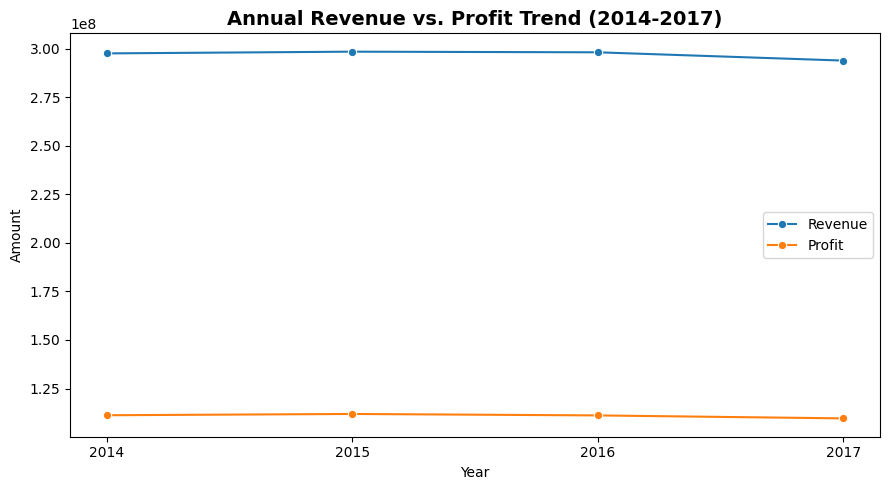

In [35]:
plt.figure(figsize=(9,5))
sns.lineplot(data=annual_perf, x='year', y='total_revenue', marker='o', label='Revenue')
sns.lineplot(data=annual_perf, x='year', y='total_profit', marker='o', label='Profit')
plt.title('Annual Revenue vs. Profit Trend (2014-2017)', fontsize=14, fontweight='bold')
plt.xticks(annual_perf['year'])
plt.xlabel('Year')
plt.ylabel('Amount')
plt.legend()
plt.tight_layout()
plt.show()

#### Observations
- Revenue is broadly **stable across 2014–2017**, peaking in 2015 (~$298M) before a slight decline to ~$294M in 2017.
- Profit closely mirrors the revenue trend, peaking in 2015 and declining modestly thereafter.
- The revenue-profit spread remains consistent year over year, indicating no structural cost shifts.


#### Interpretation
Growth is volume-driven and largely flat. The mild decline from 2015 warrants investigation at the product and regional level, but does not signal an acute business concern.

---

### 6.3 Weighted Profit Margin Trend

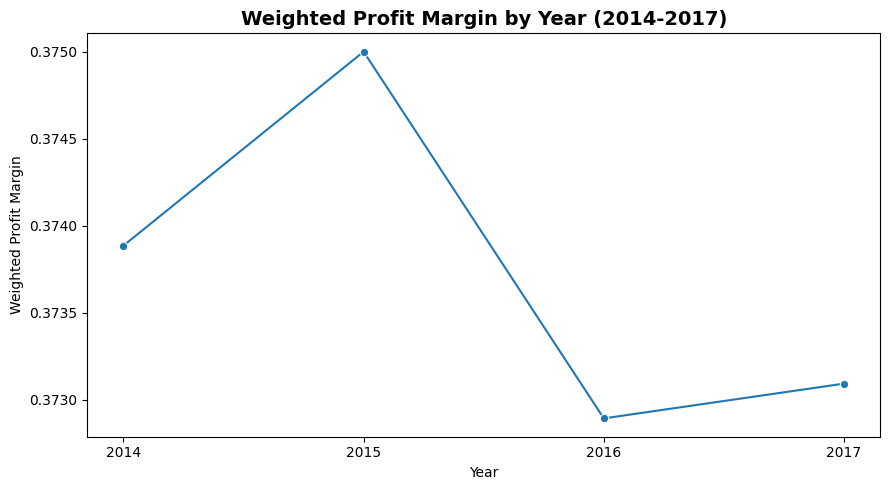

In [36]:
plt.figure(figsize=(9,5))
sns.lineplot(data=annual_perf, x='year', y='weighted_margin',marker='o')
plt.title('Weighted Profit Margin by Year (2014-2017)', fontsize=14, fontweight='bold')
plt.xticks(annual_perf['year'])
plt.xlabel('Year')
plt.ylabel('Weighted Profit Margin')
plt.tight_layout()
plt.show()


#### Observations
- Weighted margin is **remarkably stable**, ranging from **37.3% to 37.5%** across all four years.
- No year-over-year compression or structural weakening is observed.


#### Interpretation
Pricing and cost controls are well-managed at the aggregate level. Margin consistency confirms that systemic erosion is not the cause of the revenue decline. The investigation should focus on volume drivers rather than pricing or cost structure.

---


### 6.4 Revenue vs. Profit Relationship (Transaction Level)

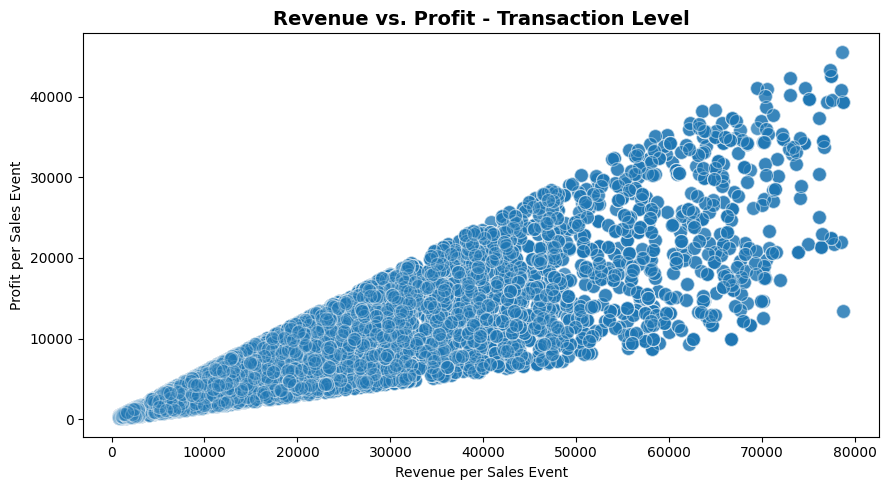

In [37]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=df_enriched, x='revenue', y='profit',alpha=0.3, s=100)
plt.title('Revenue vs. Profit - Transaction Level', fontsize=14, fontweight='bold')
plt.xlabel('Revenue per Sales Event')
plt.ylabel('Profit per Sales Event')
plt.tight_layout()
plt.show()


#### Observations
- Profit scales linearly with revenue at the transaction level - a clear, clean upward trend from near the origin.
- The spread of outcomes **widens with deal size**: small transactions show tight, consistent margins while large deals exhibit broader margin dispersion (~15%–60%).
- The data shows a clean pattern with no major anomalies, indicating healthy profit scaling with revenue.


#### Interpretation
Profit increases strongly and near-linearly with revenue, indicating a structurally consistent pricing and cost model at the transaction level.

However, margin dispersion widens as revenue increases, creating a fan-shaped pattern. This suggests that larger deals exhibit greater variability in profitability - likely due to differences in pricing strategy, product mix, or negotiated terms - though no negative-profit anomalies are observed.

---

### Section Summary — Revenue vs. Profit Reality

Aggregate revenue and profit are stable across 2014–2017, with a modest decline from the 2015 peak. Weighted margins held steady at ~37.3%–37.5%, indicating no meaningful erosion and disciplined cost/price control.

At the transaction level, profit scales reliably with revenue. Margin variability is low for small deals but widens for larger ones - consistent with a healthy, diversified portfolio.

While aggregate trends appear solid, they may mask product-, channel-, or region-specific inefficiencies. Deeper segmented analysis follows.

---

## 7. Product & Channel Profitability Analysis


### Business Purpose
Revenue concentration alone does not indicate where to invest.

This section evaluates product- and channel-level performance to understand:
- Whether profitability differs meaningfully across products or channels
- Whether revenue leaders also drive proportional profit
- Whether investment decisions should be margin-driven or volume-driven

### 7.1 Product-Level Revenue, Profit & Margin

In [38]:
product_perf = (
    df_enriched
    .groupby('product')
    .agg(
        total_revenue=('revenue', 'sum'),
        total_profit=('profit', 'sum'),
    )
    .reset_index()
    .sort_values(by='total_revenue', ascending=False)
    .reset_index(drop=True)
)

product_perf['weighted_margin']   = product_perf['total_profit'] / product_perf['total_revenue']
product_perf['revenue_share_pct'] = product_perf['total_revenue'] / product_perf['total_revenue'].sum() * 100
product_perf['profit_share_pct']  = product_perf['total_profit']  / product_perf['total_profit'].sum()  * 100

product_perf.style.format({
    'total_revenue'    : '${:,.2f}',
    'total_profit'     : '${:,.2f}',
    'weighted_margin'  : '{:.2%}',
    'revenue_share_pct': '{:.2f}%',
    'profit_share_pct' : '{:.2f}%'
})

,product,total_revenue,total_profit,weighted_margin,revenue_share_pct,profit_share_pct
0,Product 26,"$112,454,990.90","$42,521,347.53",37.81%,9.47%,9.58%
1,Product 25,"$105,715,762.40","$40,186,493.87",38.01%,8.90%,9.05%
2,Product 13,"$75,190,019.70","$27,574,419.43",36.67%,6.33%,6.21%
3,Product 14,"$72,516,666.10","$25,893,334.76",35.71%,6.10%,5.83%
4,Product 5,"$68,032,711.20","$25,479,991.59",37.45%,5.73%,5.74%
5,Product 15,"$64,933,726.70","$23,908,262.25",36.82%,5.47%,5.39%
6,Product 2,"$54,976,803.10","$19,693,022.70",35.82%,4.63%,4.44%
7,Product 4,"$54,558,669.50","$20,585,140.64",37.73%,4.59%,4.64%
8,Product 1,"$53,678,832.20","$20,595,131.14",38.37%,4.52%,4.64%
9,Product 3,"$49,935,227.30","$18,438,173.81",36.92%,4.20%,4.15%



#### Observations
- Weighted profit margins are **structurally consistent across all 30 products**, clustering tightly in the **34%-40%** range.
- No product exhibits structurally superior or inferior profitability.
- Performance differences across products are **volume-driven**, not margin-driven.



#### Interpretation
Portfolio pricing and cost control appear standardized across the product range. Profit growth opportunities lie in **scaling high-revenue products** rather than margin optimization. No immediate need for margin restructuring at the product level.


### 7.2 Top 10 Products - Revenue vs. Profit Comparison

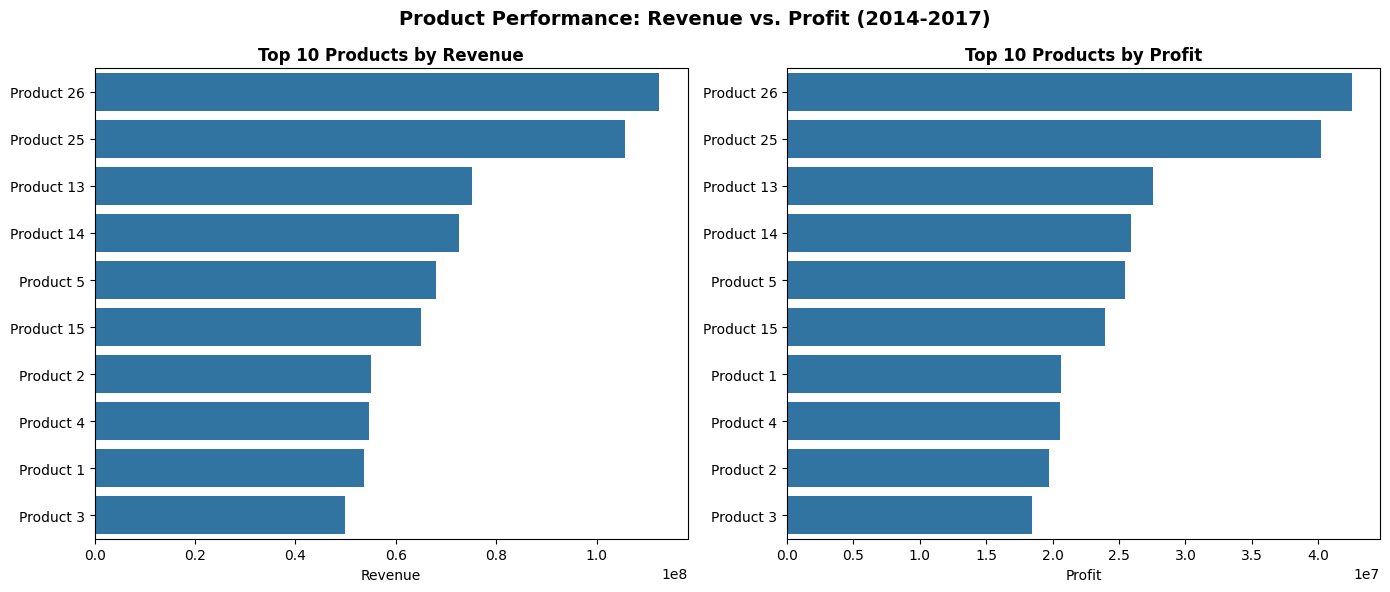

In [39]:
# Get top 10 separately
top10_revenue = product_perf.sort_values(
    'total_revenue', ascending=False
).head(10)

top10_profit = product_perf.sort_values(
    'total_profit', ascending=False
).head(10)

# Create figure and subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Revenue chart
sns.barplot(
    data=top10_revenue,
    x='total_revenue',
    y='product',
    ax=axes[0]
)
axes[0].set_title('Top 10 Products by Revenue',fontweight='bold')
axes[0].set_xlabel('Revenue')
axes[0].set_ylabel('')

# Profit chart
sns.barplot(
    data=top10_profit,
    x='total_profit',
    y='product',
    ax=axes[1]
)
axes[1].set_title('Top 10 Products by Profit',fontweight='bold')
axes[1].set_xlabel('Profit')
axes[1].set_ylabel('')

# Main title for entire figure
plt.suptitle(
    'Product Performance: Revenue vs. Profit (2014-2017)',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()


#### Observations
- The top revenue-generating products largely mirror the top profit contributors, indicating strong alignment between volume and profitability.
- Product rankings are broadly consistent across both metrics, with only minor positional shifts (e.g., Product 1 and Product 2).
- No product materially overperforms or underperforms in profit relative to its revenue contribution.


#### Interpretation
Profit differences are primarily driven by revenue scale rather than margin variation. Higher-revenue products translate proportionally into higher profit, indicating stable profitability across the product portfolio. Minor ranking shifts likely reflect small margin differences but do not suggest structural imbalance.

---

### 7.3 Channel-Level Profitability Analysis

In [40]:
channel_perf = (
    df_enriched
    .groupby('channel')
    .agg(
        total_revenue=('revenue', 'sum'),
        total_profit=('profit', 'sum'),
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
    .reset_index(drop=True)
)   

channel_perf['weighted_margin']   = channel_perf['total_profit'] / channel_perf['total_revenue']
channel_perf['revenue_share_pct'] = channel_perf['total_revenue'] / channel_perf['total_revenue'].sum() * 100

channel_perf.style.format({
    'total_revenue'    : '${:,.0f}',
    'total_profit'     : '${:,.0f}',
    'weighted_margin'  : '{:.2%}',
    'revenue_share_pct': '{:.2f}%',
})

,channel,total_revenue,total_profit,weighted_margin,revenue_share_pct
0,Wholesale,"$642,218,095","$237,874,067",37.04%,54.07%
1,Distributor,"$372,247,598","$140,115,325",37.64%,31.34%
2,Export,"$173,373,254","$65,928,924",38.03%,14.60%


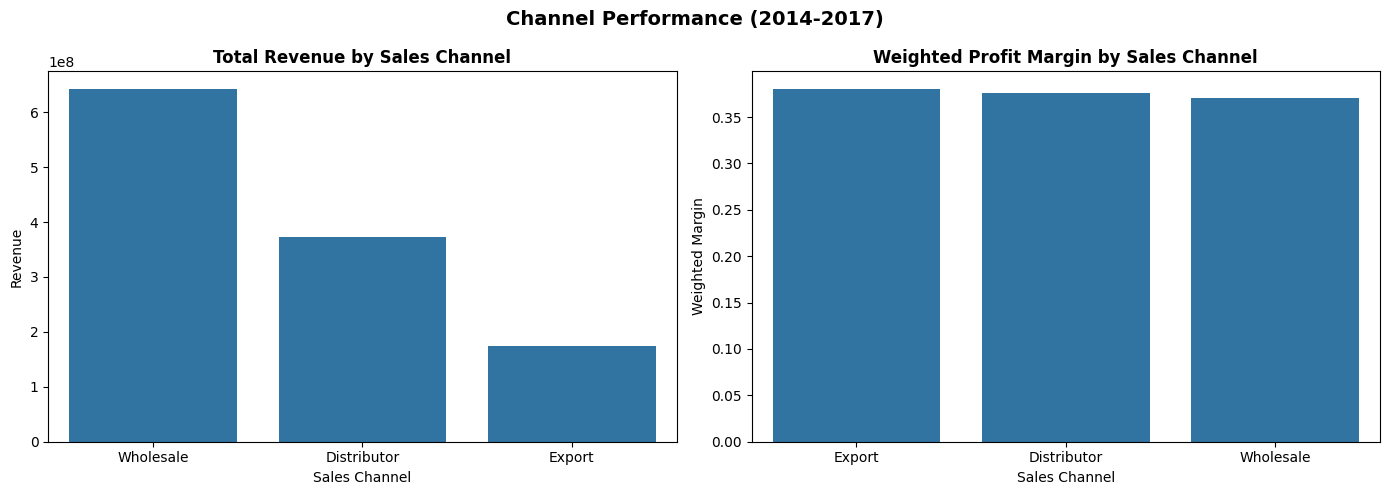

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue chart
sns.barplot(
    data=channel_perf.sort_values('total_revenue', ascending=False),
    x='channel',
    y='total_revenue',
    ax=axes[0]
)
axes[0].set_title('Total Revenue by Sales Channel',fontweight='bold')
axes[0].set_xlabel('Sales Channel')
axes[0].set_ylabel('Revenue')

# Margin chart
sns.barplot(
    data=channel_perf.sort_values('weighted_margin', ascending=False),
    x='channel',
    y='weighted_margin',
    ax=axes[1]
)
axes[1].set_title('Weighted Profit Margin by Sales Channel',fontweight='bold')
axes[1].set_xlabel('Sales Channel')
axes[1].set_ylabel('Weighted Margin')

plt.suptitle('Channel Performance (2014-2017)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


#### Observations
- **Wholesale** dominates revenue at 54.1% share (~$642M), followed by 
  Distributor (31.3%) and Export (14.6%).
- Weighted margins are consistent but show a **mild inverse pattern** - 
  Export leads at 38.03%, Distributor at 37.64%, and Wholesale trails 
  at 37.04%. Higher-volume channels carry slightly lower margins.
- The absolute margin spread across all three channels is ~1 percentage 
  point - narrow but directionally consistent.

#### Interpretation

Channel performance differences are primarily **volume-driven**. However, 
the mild inverse relationship between volume and margin - where the 
highest-volume channel (Wholesale) carries the lowest margin - suggests 
possible volume discounting or pricing concessions at scale. This does 
not disqualify Wholesale as the primary growth channel, but any scaling 
strategy should monitor whether margin compression widens as volume grows.


### Section Summary - Product & Channel Profitability

Product and channel analysis confirms that profitability is **structurally uniform** across the business. Margin differences are negligible; performance differences are driven entirely by **sales volume**. Investment decisions should prioritize scaling high-volume products and channels rather than attempting margin optimization within the current pricing and cost model.

---

## 8. Regional Performance & Concentration Analysis

### Business Purpose
With profit margins structurally uniform across products and sales channels, this section investigates whether performance differences originate from revenue distribution — and whether geographic concentration poses a risk to the business.

Specifically, this analysis answers:
- Which regions are the strongest revenue contributors?
- Is the business geographically diversified, or vulnerable to localized demand shocks?
- Are regional margin differences structural or volume-driven?

### 8.1 Regional Revenue, Profit & Margin

In [42]:
region_perf = (
    df_enriched
    .groupby(['unique_region', 'state_code'])
    .agg(
        total_revenue=('revenue', 'sum'),
        total_profit=('profit', 'sum'),
    )
    .reset_index()
    .sort_values(by='total_revenue', ascending=False)
    .reset_index(drop=True)
)

region_perf['weighted_margin']   = region_perf['total_profit'] / region_perf['total_revenue']
region_perf['revenue_share_pct'] = region_perf['total_revenue'] / region_perf['total_revenue'].sum() * 100

print(f"Total delivery regions in dataset: {len(region_perf)}")
region_perf.head(10).style.format({
    'total_revenue'     : '${:,.2f}',
    'total_profit'      : '${:,.2f}',
    'weighted_margin'   : '{:.2%}',
    'revenue_share_pct' : '{:.2f}%'
})

Total delivery regions in dataset: 993


,unique_region,state_code,total_revenue,total_profit,weighted_margin,revenue_share_pct
0,"Arlington Heights, Cook County, Illinois",IL,"$2,293,061.60","$904,250.36",39.43%,0.19%
1,"Menifee, Riverside County, California",CA,"$2,248,352.50","$764,170.51",33.99%,0.19%
2,"Lafayette, Lafayette Parish, Louisiana",LA,"$2,146,425.40","$754,666.49",35.16%,0.18%
3,"Port Orange, Volusia County, Florida",FL,"$2,133,728.90","$772,393.29",36.20%,0.18%
4,"Lakeville, Dakota County, Minnesota",MN,"$2,113,622.20","$759,818.93",35.95%,0.18%
5,"Lakewood, Jefferson County, Colorado",CO,"$2,075,258.00","$793,336.28",38.23%,0.17%
6,"Union, Broome County, New York",NY,"$2,067,492.70","$732,823.56",35.45%,0.17%
7,"Brookhaven, DeKalb County, Georgia",GA,"$2,043,707.70","$791,958.49",38.75%,0.17%
8,"Allentown, Lehigh County, Pennsylvania",PA,"$2,026,394.90","$726,557.45",35.85%,0.17%
9,"Capital, Sangamon County, Illinois",IL,"$2,000,479.30","$820,913.35",41.04%,0.17%


### 8.2 Revenue Concentration - Top Regions

In [43]:
# Concentration ratios
top1_share  = region_perf.iloc[0]['revenue_share_pct']
top3_share  = region_perf.iloc[:3]['revenue_share_pct'].sum()
top10_share = region_perf.iloc[:10]['revenue_share_pct'].sum()

print(f"Top 1 region   revenue share: {top1_share:.2f}%")
print(f"Top 3 regions  revenue share: {top3_share:.2f}%")
print(f"Top 10 regions revenue share: {top10_share:.2f}%")

Top 1 region   revenue share: 0.19%
Top 3 regions  revenue share: 0.56%
Top 10 regions revenue share: 1.78%


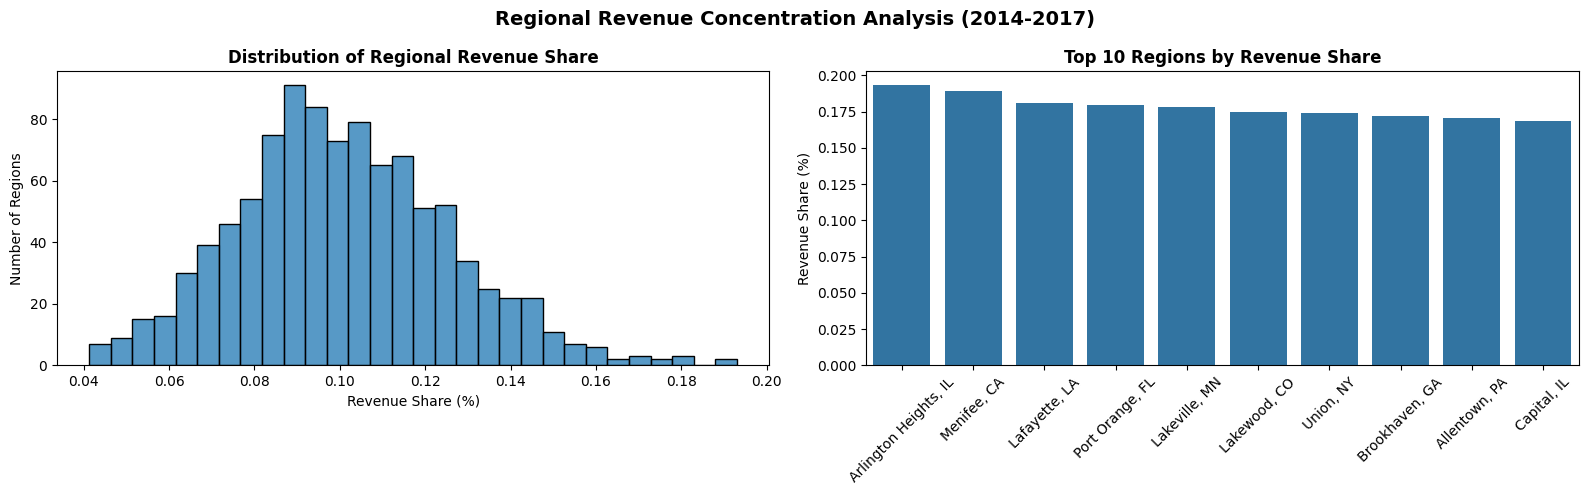

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of regional revenue share
sns.histplot(region_perf['revenue_share_pct'], bins=30, ax=axes[0])
axes[0].set_title('Distribution of Regional Revenue Share',fontweight='bold')
axes[0].set_xlabel('Revenue Share (%)')
axes[0].set_ylabel('Number of Regions')

# Top 10 regions bar chart with city-only labels
top10_regions = region_perf.head(10).copy()
top10_regions['region_label'] = top10_regions['unique_region'].str.split(',').str[0] + ', ' + top10_regions['state_code']

sns.barplot(
    data=top10_regions, x='region_label', y='revenue_share_pct', ax=axes[1]
)
axes[1].set_title('Top 10 Regions by Revenue Share',fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Revenue Share (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Regional Revenue Concentration Analysis (2014-2017)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Observations
- Revenue is distributed across **993 delivery regions** — the top 
  region (Arlington Heights, IL) contributes only **0.19%** of total 
  revenue, top 3 collectively **0.56%**, and top 10 just **1.78%**.
- The histogram confirms a highly uniform distribution — the bulk of 
  regions fall between **0.06% and 0.14%** revenue share, with no 
  region significantly above the rest and no dominant outlier visible.



#### Interpretation
Geographic concentration risk is negligible. Even a complete loss of 
revenue from the top 10 regions combined would impact total revenue by 
less than 2%. The business is highly resilient to localized demand 
disruption across its delivery footprint.

---

### 8.3 Regional Revenue Growth Trends (Top 5 Regions)

In [45]:
# Pivot: regions as rows, years as columns
regional_year_perf = (
    df_enriched
    .groupby(['year', 'unique_region'])
    .agg(total_revenue=('revenue', 'sum'))
    .reset_index()
    .pivot(index='unique_region', columns='year', values='total_revenue')
    .fillna(0)
)
regional_year_perf.columns.name = None

# Filter to top 5 regions by total revenue
top5_regions = region_perf['unique_region'].head(5)
top5_trends = regional_year_perf.loc[top5_regions]

print(top5_trends.to_string())

                                               2014       2015       2016       2017
unique_region                                                                       
Arlington Heights, Cook County, Illinois 427,734.70 704,109.70 682,703.20 478,514.00
Menifee, Riverside County, California    671,246.20 408,592.80 530,579.70 637,933.80
Lafayette, Lafayette Parish, Louisiana   467,807.40 438,293.90 556,736.50 683,587.60
Port Orange, Volusia County, Florida     506,868.40 598,122.40 508,295.50 520,442.60
Lakeville, Dakota County, Minnesota      485,629.40 690,475.20 493,870.40 443,647.20


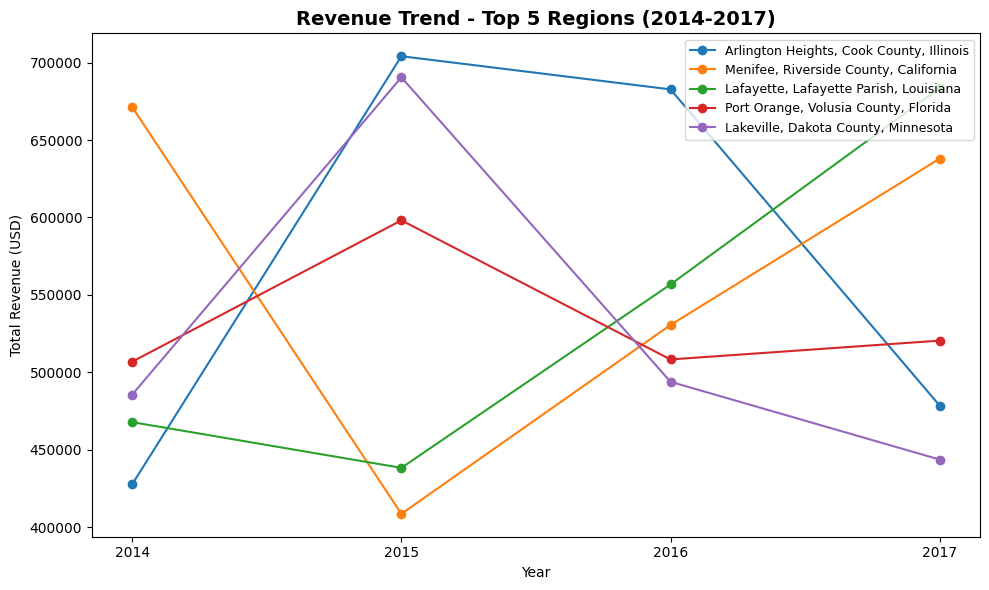

In [46]:
fig, ax = plt.subplots(figsize=(10, 6))

for region in top5_regions:
    ax.plot(
        top5_trends.columns,
        top5_trends.loc[region],
        marker='o',
        label=region
    )

ax.set_title('Revenue Trend - Top 5 Regions (2014-2017)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Revenue (USD)')
ax.set_xticks(top5_trends.columns)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

#### Observations
- Revenue trends vary significantly across top 5 regions with no 
  consistent year-over-year pattern - each region follows a distinct 
  trajectory over 2014–2017.
- **Lafayette, LA** shows steady upward momentum (~$468K → $684K), 
  while **Arlington Heights, IL** peaks in 2015 (~$704K) and declines 
  sharply by 2017 (~$479K).
- **Menifee, CA** follows an inverse pattern — strong in 2014 (~$671K), 
  drops to a low in 2015 (~$409K), then recovers by 2017 (~$638K).
- No single region maintains sustained revenue dominance across all 
  four years.

#### Interpretation
Regional revenue performance is cyclical and localized - each region's 
trajectory appears independent rather than driven by a common macro 
factor. This reinforces the diversification finding: no strategic 
dependency exists on any single geography, and volatility in one 
region is offset by stability or growth in others.

---


### Section Summary - Regional Analysis
Revenue is evenly distributed across 993 delivery regions - the top 
region contributes only 0.19% of total revenue, and the top 10 
collectively just 1.78%, confirming negligible geographic concentration 
risk. Individual region trajectories are cyclical and independent, with 
no single geography sustaining dominance across 2014–2017. The business 
demonstrates strong geographic diversification with minimal exposure to 
localized demand shocks.

---

## 9. Macro-Region Performance Analysis (Strategic Layer)

### Business Purpose
While micro-regional analysis confirmed strong diversification, executive leadership operates at the **macro-region level** (South, West, Northeast, Midwest) - aligned with sales leadership structure, resource allocation, and budget planning. This section investigates whether performance differences exist at the macro level and whether they reflect structural margin differences or volume gaps.

Specifically, this analysis answers:
- Which macro-regions contribute the most revenue and profit?
- Are margin differences structural or volume-driven at this level?
- Does any macro-region represent a disproportionate concentration risk or growth opportunity?


### 9.1 Revenue, Profit & Margin by Macro-Region

In [47]:
macro_perf = (
    df_enriched
    .groupby('macro_region')
    .agg(
        total_revenue=('revenue', 'sum'),
        total_profit=('profit', 'sum'),
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
    .reset_index(drop=True)
)

macro_perf['weighted_margin']   = macro_perf['total_profit'] / macro_perf['total_revenue']
macro_perf['revenue_share_pct'] = macro_perf['total_revenue'] / macro_perf['total_revenue'].sum() * 100

macro_perf.style.format({
    'total_revenue'    : '${:,.2f}',
    'total_profit'     : '${:,.2f}',
    'weighted_margin'  : '{:.2%}',
    'revenue_share_pct': '{:.2f}%',
})

,macro_region,total_revenue,total_profit,weighted_margin,revenue_share_pct
0,West,"$357,994,192.30","$134,124,317.36",37.47%,30.14%
1,South,"$321,673,157.30","$120,191,088.01",37.36%,27.08%
2,Midwest,"$308,316,740.80","$115,535,082.27",37.47%,25.96%
3,Northeast,"$199,854,856.10","$74,067,828.39",37.06%,16.83%


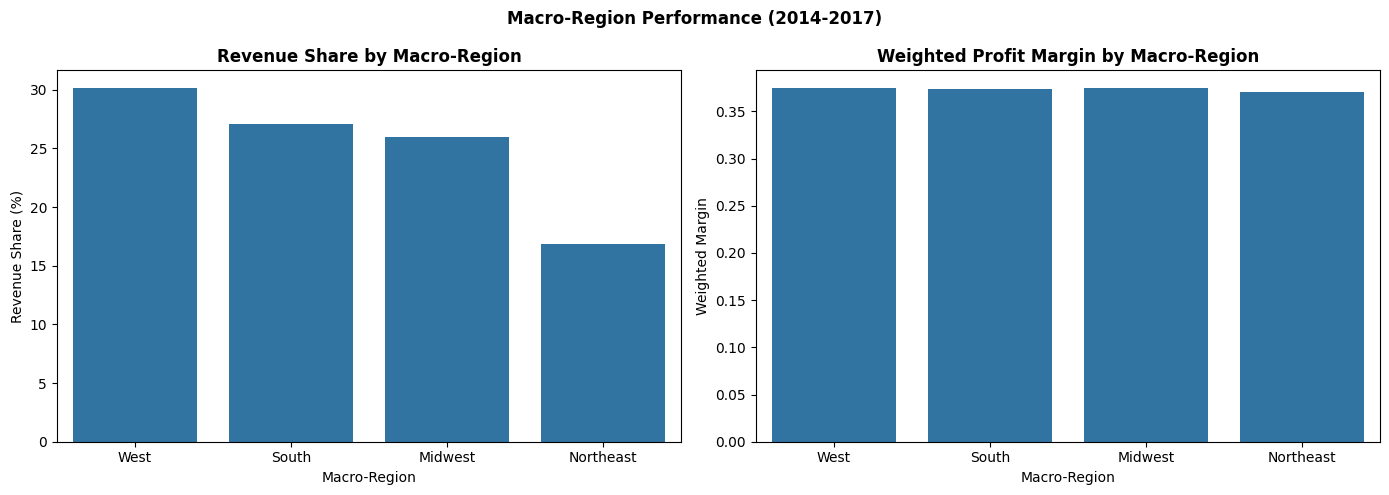

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

macro_sorted = macro_perf.sort_values('revenue_share_pct', ascending=False)

# Revenue Share chart
sns.barplot(
    data=macro_sorted,
    x='macro_region',
    y='revenue_share_pct',
    ax=axes[0]
)
axes[0].set_title('Revenue Share by Macro-Region',fontweight='bold')
axes[0].set_xlabel('Macro-Region')
axes[0].set_ylabel('Revenue Share (%)')

# Weighted Margin chart
sns.barplot(
    data=macro_sorted,
    x='macro_region',
    y='weighted_margin',
    ax=axes[1]
)
axes[1].set_title('Weighted Profit Margin by Macro-Region',fontweight='bold')
axes[1].set_xlabel('Macro-Region')
axes[1].set_ylabel('Weighted Margin')

plt.suptitle('Macro-Region Performance (2014-2017)', fontweight='bold')
plt.tight_layout()
plt.show()

#### Observations
- Revenue is distributed across four macro-regions: **West (30.1%), 
  South (27.1%), Midwest (26.0%), and Northeast (16.8%)**.
- West leads in revenue share but does not exhibit superior 
  profitability - its margin (37.47%) is identical to Midwest.
- Northeast contributes the lowest revenue share at 16.8% — 
  approximately half of West's contribution.
- Weighted margins are near-identical across all four macro-regions, 
  ranging narrowly from **37.06% (Northeast) to 37.47% (West)** — 
  a spread of just 0.41 percentage points.

#### Interpretation
Macro-region performance differences are entirely volume-driven - 
margin uniformity across all four territories confirms no structural 
profitability advantage or disadvantage exists at the macro level. 
West's revenue lead reflects greater sales volume or market 
penetration, not more profitable business. The Northeast gap (16.8% 
vs West's 30.1%) is a volume gap, not a margin problem - suggesting 
a sales coverage or market penetration opportunity rather than a 
pricing or cost issue.

---

### 9.2 Macro-Region Revenue Trend (2014-2017)

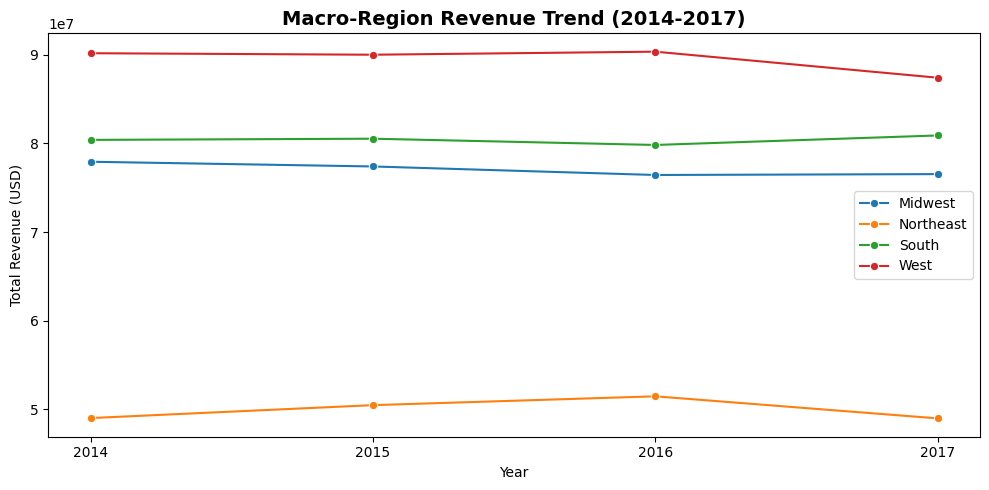

In [49]:
macro_trend = (
    df_enriched
    .groupby(['year', 'macro_region'])
    .agg(total_revenue=('revenue', 'sum'))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=macro_trend, x='year', y='total_revenue',
    hue='macro_region', marker='o', ax=ax
)

ax.set_title('Macro-Region Revenue Trend (2014-2017)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Revenue (USD)')
ax.set_xticks(macro_trend['year'].unique())
ax.legend()
plt.tight_layout()
plt.show()


#### Observations
- All four macro-regions show broadly stable revenue across 
  2014-2017 - no region exhibits a sharp rise or fall visible 
  in the trend lines.
- **West** holds the highest revenue position throughout but 
  shows a visible decline in 2017 - the most notable single 
  movement across all regions and years.
- **South** is the flattest line on the chart - revenue 
  barely moves across all four years.
- **Midwest** drifts very slightly downward across the period 
  but remains broadly flat.
- **Northeast** rises gently from 2014 to a 2016 high before 
  dropping back in 2017, ending close to where it started.
- The gap between Northeast and the other three regions is 
  large and persistent - Northeast operates at a visibly 
  lower revenue base throughout.


#### Interpretation
Macro-region revenue is mature and stable - no region is in active growth or meaningful decline across the four-year period. The 2017 West decline is the only visually material movement and warrants monitoring given West's position as the highest revenue territory. South's consistent flatness indicates a stable, predictable market. Northeast's persistent gap from the other three regions remains the primary geographic opportunity - its healthy margin confirmed in Section 9.1 means the gap is a volume problem, not a structural one.

---

### Section Summary - Macro-Region Performance
Revenue is unevenly distributed across four macro-regions - West 
leads at 30.1% and Northeast trails at 16.8%, a gap of ~13 percentage 
points. Weighted margins are uniform across all four regions (~37%), 
confirming that performance differences are volume-driven, not 
structural. Northeast represents the primary volume gap and the most 
actionable growth opportunity at the macro level.

---

## 10. Budget vs. Actual Analysis - 2017 (Product Level)

### Business Purpose
The 2017 budget sheet provides product-level revenue targets. This section assesses whether Acme Co.'s sales execution delivered against plan, and whether the planning assumptions were realistic.

Specifically, this analysis answers:
- Did actual 2017 revenue meet, exceed, or miss planned targets?
- Which products over- or underperformed, and by how much?
- Were budget assumptions structurally realistic?

### 10.1 Extract 2017 Actual Revenue by Product

In [50]:
actual_2017 = df_enriched[df_enriched['year'] == 2017]

actual_product_2017 = (
    actual_2017
    .groupby('product')
    .agg(actual_revenue=('revenue', 'sum'))
    .reset_index()
    .sort_values('actual_revenue', ascending=False)
    .reset_index(drop=True)
)

actual_product_2017

,product,actual_revenue
0,Product 25,"26,881,867.30"
1,Product 26,"26,632,272.20"
2,Product 13,"19,757,435.70"
3,Product 14,"18,580,888.90"
4,Product 5,"16,949,251.30"
5,Product 15,"15,821,380.00"
6,Product 2,"13,779,327.20"
7,Product 4,"13,587,037.20"
8,Product 1,"12,419,361.20"
9,Product 3,"11,652,130.80"


### 10.2 Prepare & Inspect Budget Data

In [51]:
# Review raw budget data, before any transformation
budget_2017

,Product Name,2017 Budgets
0,Product 1,"3,016,489.21"
1,Product 2,"3,050,087.56"
2,Product 3,"2,642,352.43"
3,Product 4,"2,885,560.82"
4,Product 5,"3,925,424.54"
5,Product 6,"1,672,229.42"
6,Product 7,"889,737.56"
7,Product 8,"1,085,037.33"
8,Product 9,"710,415.41"
9,Product 10,"864,331.62"


In [52]:
# Rename for consistency with analysis dataset
budget_2017 = budget_2017.rename(columns={
    'Product Name' : 'product',
    '2017 Budgets' : 'budget_revenue',
})

### 10.3 Merge Actual with Budget

In [53]:
budget_vs_actual_raw = actual_product_2017.merge(
    budget_2017, on='product', how='left'
)

In [54]:
# Validate no nulls - all products should have a budget entry
print("Null budget values:", budget_vs_actual_raw['budget_revenue'].isna().sum())
budget_vs_actual_raw.shape


Null budget values: 0


(30, 3)

In [55]:
# Initial variance calculation using raw budget figures
budget_vs_actual_raw['variance']     = budget_vs_actual_raw['actual_revenue'] - budget_vs_actual_raw['budget_revenue']
budget_vs_actual_raw['variance_pct'] = budget_vs_actual_raw['variance'] / budget_vs_actual_raw['budget_revenue'] * 100

budget_vs_actual_raw.sort_values('variance_pct', ascending=False).reset_index(drop=True)


,product,actual_revenue,budget_revenue,variance,variance_pct
0,Product 29,"3,755,142.30","594,471.57","3,160,670.73",531.68
1,Product 6,"9,390,880.80","1,672,229.42","7,718,651.38",461.58
2,Product 19,"9,118,981.40","1,645,841.60","7,473,139.80",454.06
3,Product 22,"3,623,829.00","663,601.90","2,960,227.10",446.08
4,Product 13,"19,757,435.70","3,720,639.65","16,036,796.05",431.02
5,Product 21,"4,931,662.30","959,899.22","3,971,763.08",413.77
6,Product 25,"26,881,867.30","5,342,315.48","21,539,551.82",403.19
7,Product 11,"6,104,128.80","1,230,458.48","4,873,670.32",396.09
8,Product 9,"3,406,749.00","710,415.41","2,696,333.59",379.54
9,Product 15,"15,821,380.00","3,299,478.31","12,521,901.69",379.51


#### Anomaly - Uniform Overperformance Detected
Initial comparison shows all products exceed budget by **238%–531%** - a uniform 
overperformance of this magnitude is statistically implausible 
as genuine business performance and strongly suggests a **data 
scale mismatch** in the budget source.

**Hypothesis:** Budget figures may represent a sub-annual period 
(monthly or quarterly) rather than full-year targets. This must 
be validated against the source budget documentation before any 
variance conclusions can be drawn.

---

### 10.4 Budget Scale Validation

In [56]:
actual_total = actual_product_2017['actual_revenue'].sum()
budget_total_raw = budget_2017['budget_revenue'].sum()

ratio = actual_total / budget_total_raw

print(f"2017 Actual Revenue  : ${actual_total:,.2f}")
print(f"Budget (raw)         : ${budget_total_raw:,.2f}")
print(f"Actual / Budget ratio: {ratio:.2f}x")
print()
print("Implication: Budget appears to be quarterly. Annualizing (x4) for comparison.")

# Annualized budget
budget_total_annualized = budget_total_raw * 4
ratio_annualized = actual_total / budget_total_annualized
print(f"Budget (annualized x4)    : ${budget_total_annualized:,.2f}")
print(f"Actual / Annualized Budget: {ratio_annualized:.2f}x  ({(ratio_annualized-1)*100:.1f}%)")

2017 Actual Revenue  : $293,823,836.80
Budget (raw)         : $62,700,262.34
Actual / Budget ratio: 4.69x

Implication: Budget appears to be quarterly. Annualizing (x4) for comparison.
Budget (annualized x4)    : $250,801,049.35
Actual / Annualized Budget: 1.17x  (17.2%)


#### Observations
- Raw budget total is approximately **4.7× smaller** than actual revenue, indicating a probable quarterly vs. annual scale mismatch.
- After annualizing (×4), actual revenue exceeds budget by approximately **17%** — a plausible outperformance figure.
- **Assumption recorded:** Budget data represents quarterly targets. Annualized (×4) values are used for all comparisons. This assumption should be confirmed with the Finance team before this analysis is used in formal reporting.

---



### 10.5 Product-Level Variance Analysis (Annualized Budget)

In [57]:
# Annualize budget
budget_annualized = budget_2017.copy()
budget_annualized['budget_revenue'] = budget_annualized['budget_revenue'] * 4

# Re-merge and calculate variance
budget_vs_actual_adj = actual_product_2017.merge(
    budget_annualized, on='product', how='left'
)

budget_vs_actual_adj['variance'] = (
    budget_vs_actual_adj['actual_revenue'] - budget_vs_actual_adj['budget_revenue']
)
budget_vs_actual_adj['variance_pct'] = (
    budget_vs_actual_adj['variance'] / budget_vs_actual_adj['budget_revenue'] * 100
)

budget_vs_actual_adj.sort_values('variance_pct', ascending=False).reset_index(drop=True).style.format({
    'actual_revenue' : '${:,.2f}',
    'budget_revenue' : '${:,.2f}',
    'variance'       : '${:,.2f}',
    'variance_pct'     : '{:+.2f}%',
})

,product,actual_revenue,budget_revenue,variance,variance_pct
0,Product 29,"$3,755,142.30","$2,377,886.28","$1,377,256.02",+57.92%
1,Product 6,"$9,390,880.80","$6,688,917.66","$2,701,963.14",+40.39%
2,Product 19,"$9,118,981.40","$6,583,366.40","$2,535,615.00",+38.52%
3,Product 22,"$3,623,829.00","$2,654,407.61","$969,421.39",+36.52%
4,Product 13,"$19,757,435.70","$14,882,558.58","$4,874,877.12",+32.76%
5,Product 21,"$4,931,662.30","$3,839,596.87","$1,092,065.43",+28.44%
6,Product 25,"$26,881,867.30","$21,369,261.94","$5,512,605.36",+25.80%
7,Product 11,"$6,104,128.80","$4,921,833.94","$1,182,294.86",+24.02%
8,Product 9,"$3,406,749.00","$2,841,661.62","$565,087.38",+19.89%
9,Product 15,"$15,821,380.00","$13,197,913.26","$2,623,466.74",+19.88%


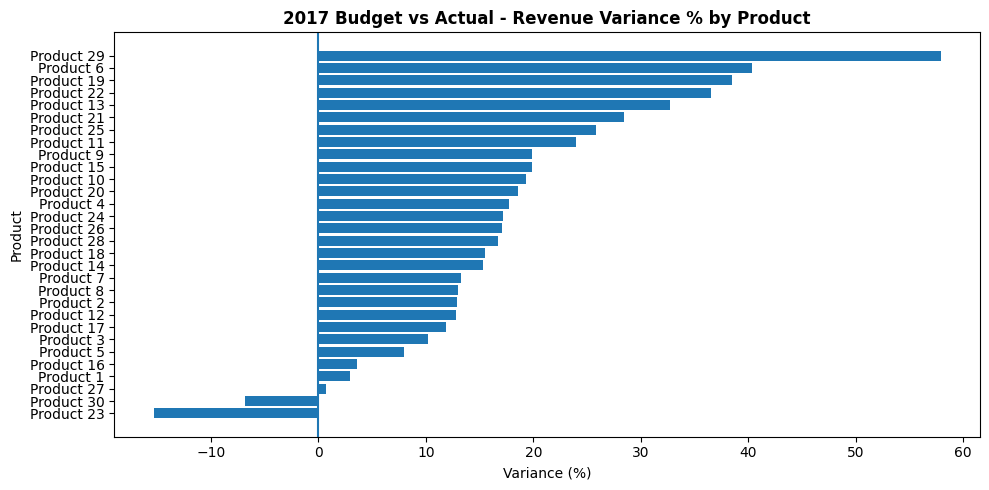

In [58]:
fig, ax = plt.subplots(figsize=(10, 5))

sorted_data = budget_vs_actual_adj.sort_values('variance_pct')

ax.barh(
    sorted_data['product'],
    sorted_data['variance_pct']
)

ax.axvline(0)

ax.set_title('2017 Budget vs Actual - Revenue Variance % by Product',fontweight='bold')
ax.set_xlabel('Variance (%)')
ax.set_ylabel('Product')

plt.tight_layout()
plt.show()


#### Observations
- **28 of 30 products** outperformed their annualized budget 
  targets in 2017.
- Variance for outperforming products ranges from **+0.7% 
  (Product 27) to +57.9% (Product 29)** - the majority cluster 
  between +10% and +30% with a visible long tail toward the top.
- Only **2 products missed budget** - Product 30 at -6.8% and 
  Product 23 at -15.3%.

#### Interpretation
Sales execution was broadly effective across the 2017 product 
portfolio. The consistent positive variance across 28 of 30 
products suggests budget assumptions were systematically 
conservative rather than reflecting a single exceptional 
performance year. The two underperforming products - Product 30 
and Product 23 - show limited deviation and do not indicate 
structural portfolio weakness, though root cause investigation 
is warranted before drawing firm conclusions

---


### Section Summary - Budget vs. Actual (2017)
After validating and annualizing quarterly budget figures, 2017 
total revenue exceeded target by approximately **17%**. 
Outperformance is broadly distributed across 28 of 30 products, 
with individual product variances ranging from **+0.7% to +57.9%** 
and the majority clustering between +10% and +30%. This reflects 
effective sales execution and structurally conservative planning 
assumptions, not windfall performance. Two products missed budget 
(Product 30 at -6.8%, Product 23 at -15.3%) - the deviation is 
limited and does not indicate structural portfolio weakness.

**Open item:** Budget periodicity (quarterly vs. annual) should 
be confirmed with Finance before this analysis is used in formal 
reporting.

---

## 11. Portfolio Risk & Concentration Analysis

### Business Purpose
The business may look healthy in aggregate while hiding dangerous dependency on a small number of products or customers. This section tests whether that risk is real by evaluating revenue and profit concentration across both the product portfolio and the customer base.

Specifically, this analysis answers:
- How much revenue and profit is generated by the top 5, top 10, and top 15 products?
- Does profit concentration mirror revenue concentration, or is there a hidden margin imbalance?
- Is the portfolio diversified enough to withstand individual product underperformance?
- How concentrated is revenue across the customer base?
- How does customer concentration compare to product concentration?
- Is the business exposed to single-customer dependency risk?

### 11.1 Revenue Concentration - Top Product Contribution

In [59]:
# Sort by revenue for revenue concentration
product_perf_sorted_rev = product_perf.sort_values(
    'revenue_share_pct', ascending=False
).reset_index(drop=True)

# Revenue concentration — top products by revenue
top5_revenue_share  = product_perf_sorted_rev.head(5)['revenue_share_pct'].sum()
top10_revenue_share = product_perf_sorted_rev.head(10)['revenue_share_pct'].sum()
top15_revenue_share = product_perf_sorted_rev.head(15)['revenue_share_pct'].sum()


print(f"Top 5  by revenue -> {top5_revenue_share:.2f}% of revenue")
print(f"Top 10 by revenue -> {top10_revenue_share:.2f}% of revenue")
print(f"Top 15 by revenue -> {top15_revenue_share:.2f}% of revenue")

Top 5  by revenue -> 36.53% of revenue
Top 10 by revenue -> 59.94% of revenue
Top 15 by revenue -> 76.47% of revenue


### 11.2 Profit Concentration - Top Product Contribution

In [60]:
# Sort by profit for profit concentration
product_perf_sorted_profit = product_perf.sort_values(
    'profit_share_pct', ascending=False
).reset_index(drop=True)

# Profit concentration — top products by profit
top5_profit_share   = product_perf_sorted_profit.head(5)['profit_share_pct'].sum()
top10_profit_share  = product_perf_sorted_profit.head(10)['profit_share_pct'].sum()
top15_profit_share  = product_perf_sorted_profit.head(15)['profit_share_pct'].sum()

print(f"Top 5  by profit  -> {top5_profit_share:.2f}% of profit")
print(f"Top 10 by profit  -> {top10_profit_share:.2f}% of profit")
print(f"Top 15 by profit  -> {top15_profit_share:.2f}% of profit")

Top 5  by profit  -> 36.42% of profit
Top 10 by profit  -> 59.67% of profit
Top 15 by profit  -> 76.36% of profit


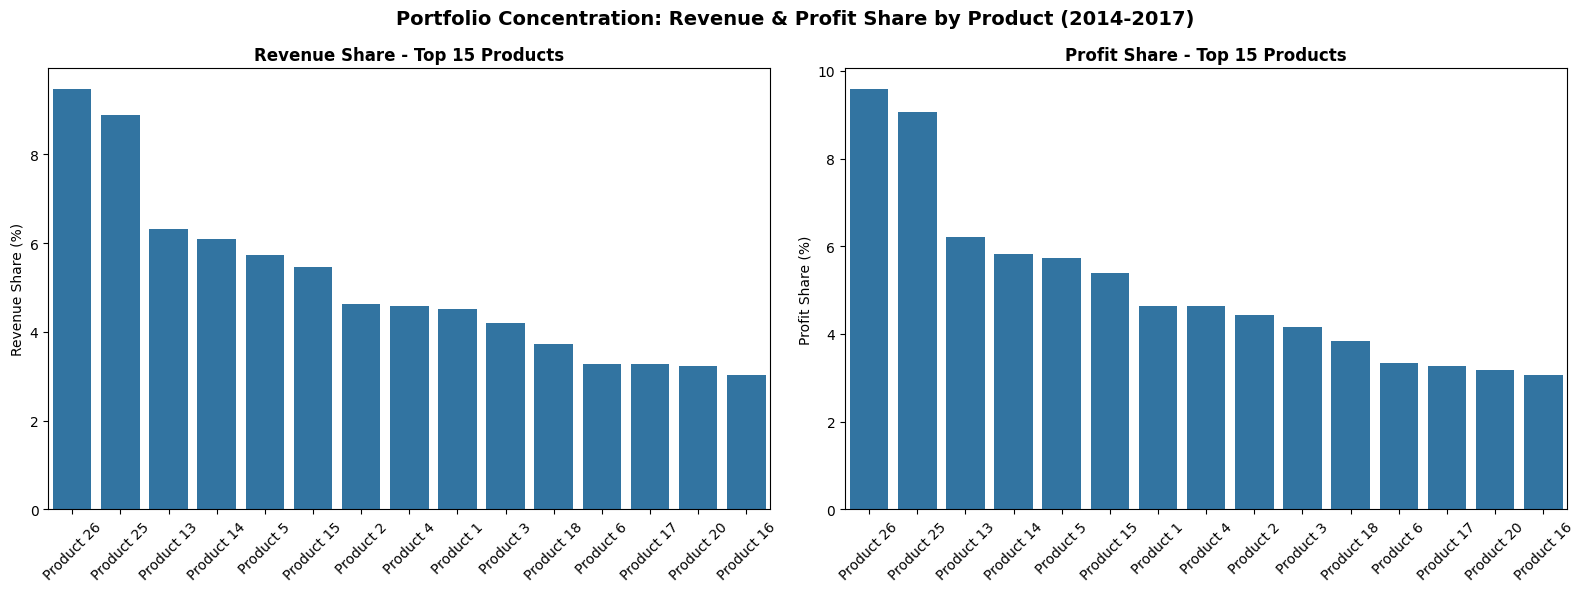

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Revenue share - Top 15
top15_rev = product_perf_sorted_rev.head(15)

sns.barplot(
    data=top15_rev,
    y='revenue_share_pct',
    x='product',
    ax=axes[0]
)
axes[0].set_title('Revenue Share - Top 15 Products',fontweight='bold')
axes[0].set_ylabel('Revenue Share (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Profit share - Top 15
top15_prof = product_perf_sorted_profit.head(15)

sns.barplot(
    data=top15_prof,
    y='profit_share_pct',
    x='product',
    ax=axes[1]
)
axes[1].set_title('Profit Share - Top 15 Products',fontweight='bold')
axes[1].set_ylabel('Profit Share (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Portfolio Concentration: Revenue & Profit Share by Product (2014-2017)',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()


#### Observations
- The **top 5 products** contribute **36.53% of total revenue** 
  and **36.42% of total profit** - a difference of just 0.11 
  percentage points.
- The **top 10 products** account for **59.94% of revenue** and 
  **59.67% of profit** - just under 60% from one third of the 
  portfolio.
- The **top 15 products** account for **76.47% of revenue** and 
  **76.36% of profit** - meaning half the portfolio (15 of 30 
  products) generates approximately three quarters of all revenue 
  and profit.
- Both charts show an **identical product ranking** - the revenue 
  and profit leaderboard is the same, confirming margin uniformity 
  at the product level.

#### Interpretation
Revenue is moderately concentrated - the top 10 products generate 
nearly 60% of total revenue - but this is distributed across 10 
distinct products rather than 1 or 2, which limits single-product 
dependency risk. Profit concentration mirrors revenue concentration 
almost exactly across all thresholds (top 5, 10, and 15), confirming 
there is no hidden margin imbalance - no product is 
disproportionately profitable or unprofitable relative to its revenue 
contribution. The portfolio is balanced and resilient to individual 
product-level underperformance.

---

### 11.3 Customer Concentration Analysis

In [62]:
# Customer-level revenue aggregation
customer_perf = (
    df_enriched.groupby('customer')
    .agg(
        total_revenue=('revenue','sum'),
        total_profit=('profit','sum'),
        total_orders=('order_number','nunique')
        )
        .reset_index()
    )

# Derived metrics
total_revenue_all = customer_perf['total_revenue'].sum()
total_profit_all = customer_perf['total_profit'].sum()

customer_perf['revenue_share_pct'] = (
    customer_perf['total_revenue'] / total_revenue_all * 100
)
customer_perf['profit_share_pct'] = (
    customer_perf['total_profit'] / total_profit_all * 100
)
customer_perf['weighted_margin'] = (
    customer_perf['total_profit'] / customer_perf['total_revenue'] * 100
)

# Sort by revenue descending
customer_perf_sorted = customer_perf.sort_values(
    'revenue_share_pct', ascending=False
).reset_index(drop=True)

print(f"Total unique customers: {len(customer_perf)}")
print(f"top 10 customers revenue:")
print(
    customer_perf_sorted[
        ['customer','total_revenue','revenue_share_pct','weighted_margin']
    ]
    .head(10)
)


Total unique customers: 175
top 10 customers revenue:
           customer  total_revenue  revenue_share_pct  weighted_margin
0     Aibox Company  12,161,136.50               1.02            39.12
1         State Ltd  11,851,757.30               1.00            39.86
2      Pixoboo Corp  10,652,242.90               0.90            36.89
3      Realbuzz Ltd  10,420,731.10               0.88            39.10
4      Organon Corp  10,390,447.10               0.87            39.70
5   WOCKHARDT Group  10,231,851.40               0.86            34.18
6         Kare Corp  10,225,345.70               0.86            34.19
7  Colgate-Pa Group   9,852,664.90               0.83            39.69
8     Deseret Group   9,697,888.20               0.82            33.97
9     Vimbo Company   9,569,080.70               0.81            38.14


In [63]:
# Revenue concentration - top customers
top5_cust_revenue = customer_perf_sorted.head(5)['revenue_share_pct'].sum()
top10_cust_revenue = customer_perf_sorted.head(10)['revenue_share_pct'].sum()
top15_cust_revenue = customer_perf_sorted.head(15)['revenue_share_pct'].sum()

# Profit concentration - top customers by profit
customer_perf_sorted_profit = customer_perf.sort_values(
    'profit_share_pct', ascending=False
).reset_index(drop=True)

top5_cust_profit  = customer_perf_sorted_profit.head(5)['profit_share_pct'].sum()
top10_cust_profit = customer_perf_sorted_profit.head(10)['profit_share_pct'].sum()
top15_cust_profit = customer_perf_sorted_profit.head(15)['profit_share_pct'].sum()

print("Customer Revenue Concentration:")
print(f" Top 5  customers -> {top5_cust_revenue:.2f}% of revenue")
print(f" Top 10 customers -> {top10_cust_revenue:.2f}% of revenue")
print(f" Top 15 customers -> {top15_cust_revenue:.2f}% of revenue")
print()
print("Customer Profit Concentration:")
print(f" Top 5  customers -> {top5_cust_profit:.2f}% of profit")
print(f" Top 10 customers -> {top10_cust_profit:.2f}% of profit")
print(f" Top 15 customers -> {top15_cust_profit:.2f}% of profit")
print()
print("Comparison vs Product Concentration:")
print(f" Product top 5  : 36.53% | Customer top 5  : {top5_cust_revenue:.2f}%")
print(f" Product top 10 : 59.94% | Customer top 10 : {top10_cust_revenue:.2f}%")
print(f" Product top 15 : 76.47% | Customer top 15 : {top15_cust_revenue:.2f}%")

Customer Revenue Concentration:
 Top 5  customers -> 4.67% of revenue
 Top 10 customers -> 8.84% of revenue
 Top 15 customers -> 12.75% of revenue

Customer Profit Concentration:
 Top 5  customers -> 4.87% of profit
 Top 10 customers -> 9.03% of profit
 Top 15 customers -> 12.97% of profit

Comparison vs Product Concentration:
 Product top 5  : 36.53% | Customer top 5  : 4.67%
 Product top 10 : 59.94% | Customer top 10 : 8.84%
 Product top 15 : 76.47% | Customer top 15 : 12.75%


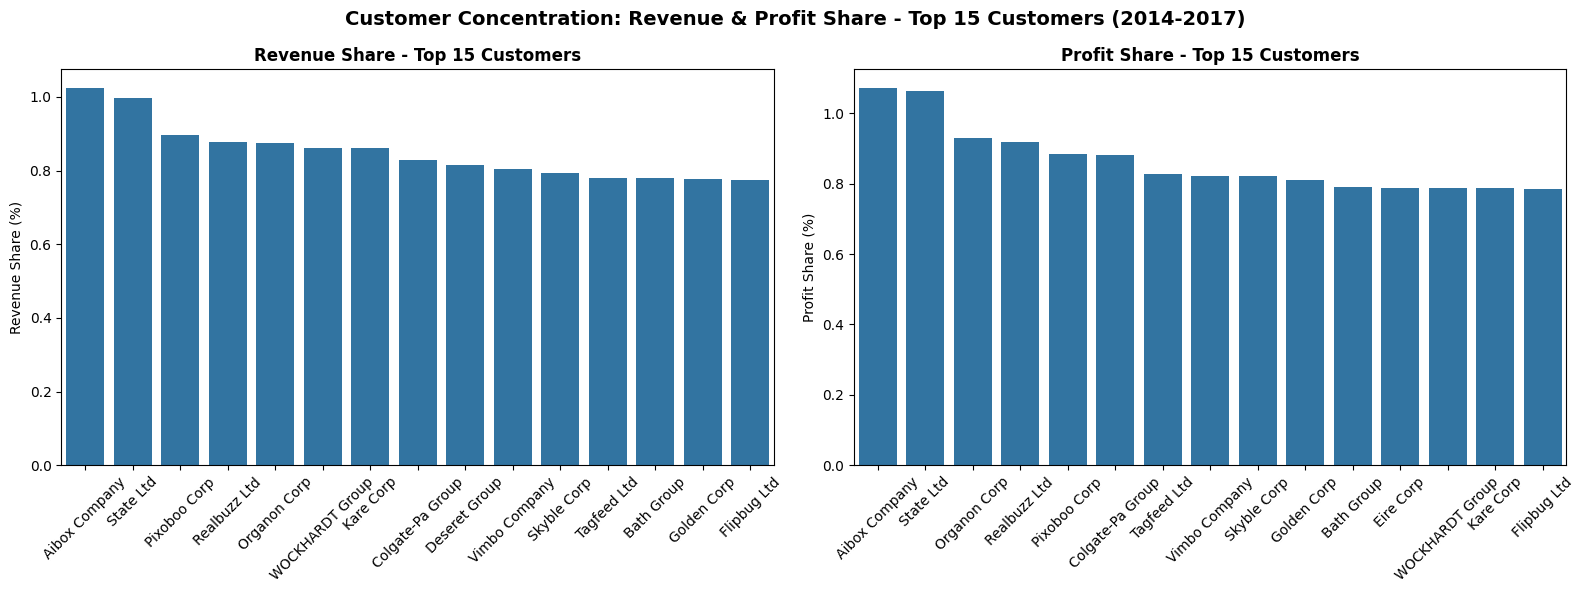

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Revenue share - Top 15 customers
top15_cust_rev = customer_perf_sorted.head(15)

sns.barplot(
    data=top15_cust_rev,
    y='revenue_share_pct',
    x='customer',
    ax=axes[0],
)
axes[0].set_title('Revenue Share - Top 15 Customers', fontweight='bold')
axes[0].set_ylabel('Revenue Share (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x',rotation=45)

# Profit share - Top 15 customers
top15_cust_prof = customer_perf_sorted_profit.head(15)

sns.barplot(
    data=top15_cust_prof,
    y='profit_share_pct',
    x='customer',
    ax=axes[1],
)
axes[1].set_title('Profit Share - Top 15 Customers', fontweight='bold')
axes[1].set_ylabel('Profit Share (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle(
    'Customer Concentration: Revenue & Profit Share - Top 15 Customers (2014-2017)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()


#### Observations

- The dataset contains 175 unique customers - revenue is distributed across a large and fragmented customer base.
- The top customer (Aibox Company) contributes just 1.02% of total revenue - no single account holds meaningful dominance.
- The top 5 customers collectively account for 4.67% of revenue and 4.87% of profit - a difference of just 0.20 percentage points.
- The top 10 customers account for 8.84% of revenue and 9.03% of profit.
- The top 15 customers account for 12.75% of revenue and 12.97% of profit.
-The revenue portfolio is significantly more concentrated at the product level than at the customer level. The top 10 products (one-third of the portfolio) generate 59.9% of revenue, whereas the top 15 customers - representing less than 9% of the customer base - contribute only 12.8%. This indicates revenue risk is primarily driven by product concentration rather than dependency on a small set of customers.
- Revenue and profit rankings are closely aligned across the customer base, consistent with the margin uniformity observed at product, channel, and regional level throughout this analysis.

#### Interpretation

Customer concentration risk is negligible. The top 15 customers combined account for under 13% of total revenue — meaning even the complete simultaneous loss of the 15 largest accounts would leave 87% of revenue intact. This level of fragmentation across 175 customers represents a significant structural strength: the business carries virtually no single-customer dependency risk. The tight alignment between revenue and profit share at every threshold confirms no customer is disproportionately profitable or unprofitable relative to their revenue contribution — the uniform margin structure observed across products, channels, and regions extends fully to the customer dimension as well.

---

### Section Summary - Portfolio Risk & Concentration
Product concentration is moderate - the top 10 products account for ~60% and the top 15 for ~76% of total revenue - but distributed across enough products to limit single-product dependency risk. Profit generation is proportionally aligned with revenue at every concentration threshold, confirming no hidden margin imbalance.

Customer concentration is substantially lower than product concentration at every threshold. Across 175 customers, the top 10 accounts contribute just 8.84% of revenue and the top 15 just 12.75% - confirming the customer base is highly fragmented with no individual account representing meaningful dependency risk.

Across both dimensions - product and customer - the portfolio is structurally balanced and resilient. No concentration risk requiring remediation was identified.

---

## 12. Executive Summary & Strategic Recommendations

### Overall Assessment

Acme Co.'s sales performance across 2014-2017 reflects a **stable, well-managed, and structurally diversified** business with consistent profitability. No signs of systemic margin erosion or dangerous revenue concentration were identified.

---

### Key Findings

| Dimension | Finding | Risk Level |
|---|---|---|
| Revenue trend | Broadly stable 2014-2016; decline concentrated in 2017 (-1.5% from 2015 peak) | Low |
| Profit margin | ~37.3%–37.5% weighted; zero erosion across 4 years | Low |
| Product mix | Margins uniform across all 30 products; volume-driven differences | Low |
| Channel mix | Margins identical across Wholesale, Distributor, Export | Low |
| Regional concentration | 993 regions; top region < 0.2% of revenue | Very Low |
| Macro-region | West leads (30%); Northeast lags (17%) by volume only | Low-Medium |
| Budget performance | +17% outperformance in 2017; 28 of 30 products exceeded target | Positive |
| Portfolio concentration | Top 10 products = ~60% revenue; balanced, no undue dependency | Moderate |
| Customer concentration | 175 customers; top 10 = 8.84% revenue; highly fragmented, no single-account dependency | Very Low |

<br>

---

### Strategic Recommendations
The following recommendations are prioritised by business impact and analytical confidence, moving from structural findings to items requiring further validation.

1. **Prioritise volume growth over margin improvement.** Margins are structurally stable across all dimensions (~37.3%-37.5% across four years). The mild revenue softness from the 2015 peak (-1.5%) confirms that any performance improvement must come from volume growth - not pricing or cost restructuring.

2. **Investigate the Northeast gap.** Northeast contributes only ~17% of revenue vs. ~27-30% for other macro-regions. Given uniform margins, this is a **market penetration / sales coverage opportunity**, not a profitability issue.

3. **Scale top-revenue products.** The top 10 products generate ~60% of revenue with identical margins - scaling them further will proportionally lift total profit.

4. **Confirm budget periodicity with Finance.** The quarterly-vs-annual budget assumption is critical for accurate 2017 reporting. Variance figures change materially depending on this interpretation.

5. **Investigate the 2 underperforming products.** While deviation is minor, root-cause analysis (market saturation, pricing, channel coverage) is warranted before the next planning cycle.

6. **Monitor West macro-region trend going forward.** The 2017 revenue decline in West - the highest-contributing territory at ~30% of total revenue - warrants attention in 2018 reporting once full-year data is available.

---